# 5a_QRF_TARGETS

Apply trained QRF model to Antarctic and Greenland target grids.

**Outputs per region** (single pass, all quantiles):

| Variable | Description |
|---|---|
| `qrf_q05/q25/q50/q75/q95_raw` | Raw quantile predictions |
| `qrf_q05/q25/q50/q75/q95_corr` | Spline-corrected (Q50 shift applied) |
| `qrf_iqr50/iqr90_raw/corr` | Inter-quantile ranges |
| `qrf_sigma_raw/corr` | Gaussian-equiv σ from IQR90 |

**Spline correction:** PCHIP spline fitted on calibration Q50. Applied to Q50 only.
Other quantiles shifted by the same additive offset (interval widths preserved).

**Shannon H:** Normalised entropy of Q50 field stored as global dataset attribute.

**Files written:**
- `output/targets/Aq1_5_QRF_v{MODEL_VERSION}.nc` — Antarctica
- `output/targets/Kq1_5_QRF_v{MODEL_VERSION}.nc` — Greenland

> Requires: `output/models/qrf_artefacts.pkl` (written by `4a_QRF_MODEL`)

## 0. Config patch check

In [1]:
# ── config.py additions needed ───────────────────────────────────────────────
# Add these lines to config.py if not already present:
#
# MODEL_VERSION = '0_2'
#
# model_paths update — add Q25 and Q75 GBM:
# model_paths = {
#     'qrf'       : model_dir / 'qrf_model.pkl',
#     'gbm_q05'   : model_dir / 'gbm_q05_model.pkl',
#     'gbm_q25'   : model_dir / 'gbm_q25_model.pkl',
#     'gbm_q50'   : model_dir / 'gbm_q50_model.pkl',
#     'gbm_q75'   : model_dir / 'gbm_q75_model.pkl',
#     'gbm_q95'   : model_dir / 'gbm_q95_model.pkl',
#     'sim_correction': model_dir / 'sim_correction_spline.pkl',
#     'model_metrics' : model_dir / 'model_metrics.csv',
# }
#
# Each GBM artefact pkl is produced by 4b_GBM_MODEL for each quantile.
# The pkl must contain keys: 'model','scaler','spline','obs_sel','PARAMS'
print('Config note displayed.')


Config note displayed.


## 1. Imports & constants

In [31]:
import sys, json, pickle, warnings, datetime
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from config import (
    obs_model, q_clip_min, q_clip_max, random_state, q_min, q_max,
    ant_crs, grl_crs, model_dir, targets_dir, param_paths,
    netcdf_compression_level, NETCDF_AUTHOR, NETCDF_CONVENTIONS,
    PRED_QUANTILES, TARGET_GRIDS, MODEL_VERSION,
)
targets_dir.mkdir(parents=True, exist_ok=True)
QUANTILES = PRED_QUANTILES   # [0.05, 0.25, 0.50, 0.75, 0.95]
Q50_IDX   = QUANTILES.index(0.50)
print(f'quantiles    : {QUANTILES}')
print(f'model version: {MODEL_VERSION}')
print(f'targets_dir  : {targets_dir}')


quantiles    : [0.05, 0.25, 0.5, 0.75, 0.95]
model version: 0_2
targets_dir  : output/targets


## 2. Helpers

In [3]:
# ── Grid loader ───────────────────────────────────────────────────────────────
def load_grid(grid_cfg, obs_sel):
    label, xcol, ycol = grid_cfg['label'], grid_cfg['x_col'], grid_cfg['y_col']
    df = pd.read_parquet(grid_cfg['parquet'])
    print(f'\n[{label.upper()}] {len(df):,} rows')
    missing = [f for f in obs_sel if f not in df.columns]
    if missing:
        warnings.warn(f'Missing features {missing} — filling NaN')
        for f in missing: df[f] = np.nan
    nan_cols = {f: int(df[f].isna().sum()) for f in obs_sel if df[f].isna().any()}
    if nan_cols: print(f'  NaN counts: {nan_cols}')
    else: print(f'  All {len(obs_sel)} features OK, no NaNs')
    x_vals = np.sort(df[xcol].unique()).astype(np.float64)
    y_vals = np.sort(df[ycol].unique()).astype(np.float64)
    nx, ny = len(x_vals), len(y_vals)
    is_reg = (len(df) == nx * ny)
    if is_reg:
        dx, dy = np.diff(x_vals), np.diff(y_vals)
        print(f'  Regular {ny}x{nx}  dx={dx[0]:.0f}m dy={dy[0]:.0f}m')
    else:
        print(f'  Irregular {len(df):,} pts (expected {ny*nx:,}) — griddata fallback')
    return df, x_vals, y_vals, ny, nx, is_reg

def build_X(df, obs_sel, scaler):
    X_raw  = df[obs_sel].values.astype(np.float32)
    finite = np.isfinite(X_raw).all(axis=1)
    X_sc   = np.full_like(X_raw, np.nan)
    if finite.any():
        X_sc[finite] = scaler.transform(X_raw[finite]).astype(np.float32)
    print(f'  finite points: {finite.sum():,} / {len(df):,}')
    return X_sc, finite

def to_2d(vals_1d, df, x_vals, y_vals, xcol, ycol, is_reg):
    ny, nx = len(y_vals), len(x_vals)
    if is_reg:
        tmp = df[[xcol, ycol]].copy()
        tmp['_v'] = vals_1d
        return tmp.pivot(index=ycol, columns=xcol, values='_v').values.astype(np.float32)
    from scipy.interpolate import griddata
    gx, gy = np.meshgrid(x_vals, y_vals)
    return griddata(df[[xcol, ycol]].values, vals_1d, (gx, gy), method='nearest').astype(np.float32)

def apply_spline(spline, vals):
    out = np.full(vals.shape, np.nan, dtype=np.float32)
    ok  = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), q_clip_min, q_clip_max)
    return out

def shannon_H_norm(values_2d, bin_width=0.010):
    v = values_2d.ravel()
    v = v[np.isfinite(v)]
    if len(v) == 0: return np.nan
    bins = np.arange(q_clip_min, q_clip_max + bin_width, bin_width)
    counts, _ = np.histogram(v, bins=bins)
    p = counts / counts.sum()
    p = p[p > 0]
    H = float(scipy_entropy(p))
    H_max = float(np.log(len(bins) - 1))
    return round(H / H_max, 6) if H_max > 0 else 0.0

def make_ds(arrays, x_vals, y_vals, grid_cfg, params, obs_sel, model_tag, extra=None):
    coords = {'y': y_vals, 'x': x_vals}
    dvars = {name: xr.DataArray(arr, dims=['y','x'], coords=coords,
                                attrs={'units':'W m-2','long_name':name.replace('_',' ')})
             for name, arr in arrays.items()}
    ds = xr.Dataset(dvars, coords=coords)
    attrs = dict(
        title=f'{model_tag} heat-flow prediction',
        model=model_tag, version=MODEL_VERSION,
        institution=NETCDF_AUTHOR, Conventions=NETCDF_CONVENTIONS,
        crs=grid_cfg['crs'], epsg=str(grid_cfg['epsg']),
        region=grid_cfg['label'].upper(),
        created=datetime.datetime.utcnow().isoformat()+'Z',
        obs_sel=json.dumps(obs_sel),
        quantiles=json.dumps(QUANTILES),
        q_clip_min=float(q_clip_min), q_clip_max=float(q_clip_max),
        params_json=json.dumps(params, default=str),
    )
    if extra: attrs.update(extra)
    ds.attrs = attrs
    return ds

def save_nc(ds, path):
    enc = {v: {'zlib':True,'complevel':netcdf_compression_level,'dtype':'float32'}
           for v in ds.data_vars}
    ds.to_netcdf(path, encoding=enc)
    print(f'  Saved {path}  ({path.stat().st_size/1e6:.1f} MB)')

print('Helpers ready.')


Helpers ready.


## 3. Load QRF artefacts

In [5]:
## 3. Load QRF artefacts

with open(model_dir / 'qrf_artefacts.pkl', 'rb') as fp:
    art = pickle.load(fp)

qrf      = art['qrf']
scaler   = art['scaler']
spline   = art['qrf_spline']
obs_sel  = art['obs_sel']
PARAMS   = art['PARAMS']
qhat_qrf = art['qhat_qrf']

print(f'QRF loaded  n_estimators={qrf.n_estimators}  features={len(obs_sel)}')
print(f'obs_sel: {obs_sel}')
print(f'qhat_qrf: {qhat_qrf:.6f}')

QRF loaded  n_estimators=1000  features=21
obs_sel: ['MOHO', 'MOHO_GRAV', 'DEM', 'LAB', 'FREE_AIR', 'BOUGUER', 'SI', 'GEOID', 'REVEAL_S80', 'REVEAL_S90', 'REVEAL_S70', 'REVEAL_S100', 'REVEAL_VP60VS70', 'REVEAL_VP90VS60', 'REVEAL_VP50VS80', 'LITH_RHO', 'CRUST_RHO', 'MAG_SEIS_MOHO', 'SEDIMENT', 'CTD', 'EMAG2_LOG']
qhat_qrf: -0.003000


## 4. Predict & write netCDF

Loops over `TARGET_GRIDS` (ant + grl). For each:
1. Load parquet, verify features, check grid regularity
2. Scale features with train-fold scaler
3. Single `qrf.predict(X, quantiles=[...])` call
4. Apply Q50 spline correction, propagate offset to all quantiles
5. Compute IQR50, IQR90, σ
6. Reshape 1D → 2D (y, x)
7. Write compressed netCDF with metadata

In [6]:
import time
results_qrf = {}

for grid_cfg in TARGET_GRIDS:
    label = grid_cfg['label']
    prefix = 'Aq1_5' if label == 'ant' else 'Kq1_5'
    out_path = targets_dir / f'{prefix}_QRF_v{MODEL_VERSION}.nc'

    df, x_vals, y_vals, ny, nx, is_reg = load_grid(grid_cfg, obs_sel)
    X_sc, finite = build_X(df, obs_sel, scaler)
    xcol, ycol = grid_cfg['x_col'], grid_cfg['y_col']

    # ── QRF prediction (single pass, all quantiles) ──────────────────────
    print(f'  Predicting {len(df):,} points × {len(QUANTILES)} quantiles ...')
    t0 = time.time()
    q_preds = np.full((len(df), len(QUANTILES)), np.nan, dtype=np.float32)
    q_preds[finite] = qrf.predict(
        X_sc[finite], quantiles=QUANTILES
    ).astype(np.float32)
    print(f'  QRF predict wall time: {(time.time()-t0)/60:.1f} min')

    # ── clip to physical range ────────────────────────────────────────────
    q_preds = np.clip(q_preds, q_clip_min, q_clip_max)

    # ── spline correction on Q50; offsets for other quantiles ─────────────
    q50_raw  = q_preds[:, Q50_IDX]
    q50_corr = apply_spline(spline, q50_raw)
    offset   = q50_corr - q50_raw                 # additive shift

    arrays = {}
    qnames = ['q05','q25','q50','q75','q95']
    for qi, qn in enumerate(qnames):
        raw_1d  = q_preds[:, qi]
        corr_1d = np.clip(raw_1d + offset, q_clip_min, q_clip_max)
        arrays[f'qrf_{qn}_raw' ] = to_2d(raw_1d,  df, x_vals, y_vals, xcol, ycol, is_reg)
        arrays[f'qrf_{qn}_corr'] = to_2d(corr_1d, df, x_vals, y_vals, xcol, ycol, is_reg)

    # ── derived uncertainty metrics ───────────────────────────────────────
    iqr50_raw  = q_preds[:,3] - q_preds[:,1]          # Q75-Q25
    iqr90_raw  = q_preds[:,4] - q_preds[:,0]          # Q95-Q05
    sigma_raw  = iqr90_raw / (2 * 1.6449)             # Gaussian-equiv sigma
    iqr50_corr = np.clip(iqr50_raw + 0, 0, q_clip_max)  # offsets cancel in IQR
    iqr90_corr = np.clip(iqr90_raw + 0, 0, q_clip_max)
    sigma_corr = iqr90_corr / (2 * 1.6449)

    for name, arr1d in [
        ('qrf_iqr50_raw',  iqr50_raw),  ('qrf_iqr90_raw',  iqr90_raw),
        ('qrf_sigma_raw',  sigma_raw),
        ('qrf_iqr50_corr', iqr50_corr), ('qrf_iqr90_corr', iqr90_corr),
        ('qrf_sigma_corr', sigma_corr),
    ]:
        arrays[name] = to_2d(arr1d, df, x_vals, y_vals, xcol, ycol, is_reg)

    # ── Shannon entropy (normalised, scalar attribute) ────────────────────
    H_raw  = shannon_H_norm(arrays['qrf_q50_raw'])
    H_corr = shannon_H_norm(arrays['qrf_q50_corr'])
    print(f'  Shannon H (norm): raw={H_raw:.4f}  corr={H_corr:.4f}')

    # ── build & save dataset ──────────────────────────────────────────────
    ds = make_ds(arrays, x_vals, y_vals, grid_cfg, PARAMS, obs_sel,
                 model_tag=f'{prefix}_QRF',
                 extra={'shannon_H_q50_raw': H_raw,
                        'shannon_H_q50_corr': H_corr,
                        'spline_applied': 'Q50 only; other quantiles shifted by Q50 offset'})
    save_nc(ds, out_path)
    results_qrf[label] = ds
    print(f'  [{label.upper()}] done.')

print('\nAll QRF target grids complete.')



[ANT] 1,779,556 rows
  NaN counts: {'DEM': 383490}
  Regular 1334x1334  dx=5000m dy=5000m
  finite points: 1,396,066 / 1,779,556
  Predicting 1,779,556 points × 5 quantiles ...
  QRF predict wall time: 38.3 min
  Shannon H (norm): raw=0.3476  corr=0.3768
  Saved output/targets/Aq1_5_QRF_v0_2.nc  (51.4 MB)
  [ANT] done.

[GRL] 172,360 rows
  All 21 features OK, no NaNs
  Regular 556x310  dx=4950m dy=4950m
  finite points: 172,360 / 172,360
  Predicting 172,360 points × 5 quantiles ...
  QRF predict wall time: 16.3 min
  Shannon H (norm): raw=0.3835  corr=0.4119
  Saved output/targets/Kq1_5_QRF_v0_2.nc  (6.7 MB)
  [GRL] done.

All QRF target grids complete.


## 5. Summary statistics

In [7]:
for label, ds in results_qrf.items():
    print(f'\n[{label.upper()}] variables:')
    for v in ds.data_vars:
        arr = ds[v].values
        fin = arr[np.isfinite(arr)]
        print(f'  {v:30s}  mean={fin.mean()*1e3:.1f}  '
              f'std={fin.std()*1e3:.1f}  '
              f'[{fin.min()*1e3:.1f}, {fin.max()*1e3:.1f}] mW/m2')



[ANT] variables:
  qrf_q05_raw                     mean=23.8  std=5.2  [2.0, 40.0] mW/m2
  qrf_q05_corr                    mean=23.1  std=5.5  [1.0, 43.5] mW/m2
  qrf_q25_raw                     mean=41.8  std=5.4  [18.0, 81.3] mW/m2
  qrf_q25_corr                    mean=41.1  std=6.5  [12.4, 92.4] mW/m2
  qrf_q50_raw                     mean=56.7  std=8.5  [29.3, 128.0] mW/m2
  qrf_q50_corr                    mean=56.1  std=10.0  [23.2, 141.9] mW/m2
  qrf_q75_raw                     mean=75.3  std=16.9  [45.0, 238.0] mW/m2
  qrf_q75_corr                    mean=74.6  std=18.3  [38.8, 246.3] mW/m2
  qrf_q95_raw                     mean=134.4  std=61.3  [62.5, 350.0] mW/m2
  qrf_q95_corr                    mean=133.7  std=62.1  [60.6, 350.0] mW/m2
  qrf_iqr50_raw                   mean=33.5  std=14.8  [11.2, 181.1] mW/m2
  qrf_iqr90_raw                   mean=110.6  std=61.4  [38.0, 342.9] mW/m2
  qrf_sigma_raw                   mean=33.6  std=18.7  [11.6, 104.2] mW/m2
  qrf_iqr50_cor

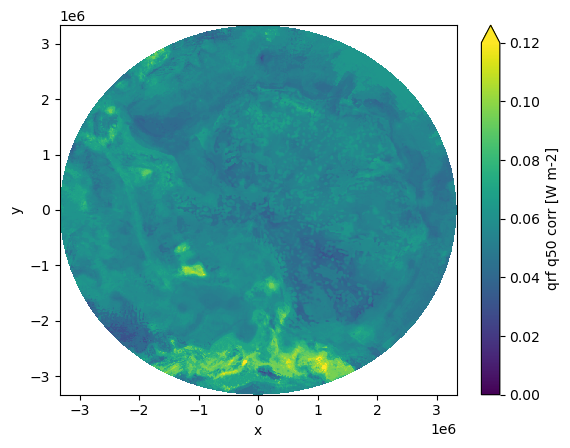

In [36]:
results_qrf['ant']['qrf_q50_corr'].plot(vmin = q_min, vmax = 0.12)

In [41]:
grl.map(results_qrf['grl']['qrf_q50_corr'])

#results_qrf['grl']['qrf_q50_corr'].plot(vmin = q_min, vmax = 0.12)

NameError: name 'grl' is not defined

In [27]:
results_qrf['grl']

<xarray.Dataset> Size: 11MB
Dimensions:         (y: 556, x: 310)
Coordinates:
  * y               (y) float64 4kB -3.38e+06 -3.375e+06 ... -6.327e+05
  * x               (x) float64 2kB -6.529e+05 -6.48e+05 ... 8.717e+05 8.766e+05
Data variables: (12/16)
    qrf_q05_raw     (y, x) float32 689kB 0.021 0.02599 ... 0.04019 0.03923
    qrf_q05_corr    (y, x) float32 689kB 0.02 0.02499 ... 0.04619 0.04423
    qrf_q25_raw     (y, x) float32 689kB 0.046 0.046 0.046 ... 0.06533 0.0643
    qrf_q25_corr    (y, x) float32 689kB 0.045 0.045 0.045 ... 0.07133 0.0693
    qrf_q50_raw     (y, x) float32 689kB 0.056 0.056 0.056 ... 0.091 0.084 0.082
    qrf_q50_corr    (y, x) float32 689kB 0.055 0.055 0.055 ... 0.09 0.087
    ...              ...
    qrf_iqr50_raw   (y, x) float32 689kB 0.019 0.019 0.019 ... 0.04642 0.0457
    qrf_iqr90_raw   (y, x) float32 689kB 0.0722 0.06414 ... 0.1088 0.1099
    qrf_sigma_raw   (y, x) float32 689kB 0.02195 0.0195 ... 0.03307 0.0334
    qrf_iqr50_corr  (y, x) float32 689kB 0.019 0.019 0.019 ... 0.04642 0.0457
    qrf_iqr90_corr  (y, x) float32 689kB 0.0722 0.06414 ... 0.1088 0.1099
    qrf_sigma_corr  (y, x) float32 689kB 0.02195 0.0195 ... 0.03307 0.0334
Attributes: (12/17)
    title:               Kq1_5_QRF heat-flow prediction
    model:               Kq1_5_QRF
    version:             0_2
    institution:         Stål et al. (Aq2/Kq2)
    Conventions:         CF-1.8
    crs:                 EPSG:3413
    ...                  ...
    q_clip_min:          0.001
    q_clip_max:          0.35
    params_json:         {"model": "QRF", "sweep_notebook": "3a_QRF_SWEEP", "...
    shannon_H_q50_raw:   0.383529
    shannon_H_q50_corr:  0.411913
    spline_applied:      Q50 only; other quantiles shifted by Q50 offset